# **DRUG & SMILE : Analyse et Prédiction**

Ce projet a pour objectif de prédire les **interactions** entre des molécules et **trois protéines distinctes** (à savoir **BRD4**, **HSA** et **sEH**) en utilisant des représentations **SMILES**.

Il s'appuie sur le **challenge Kaggle** disponible via ce lien : [https://www.kaggle.com/competitions/leash-BELKA/overview](https://www.kaggle.com/competitions/leash-BELKA/overview).

Dans ce projet, nous transformerons les données **SMILES** en données **ECFP**.  
L'**ECFP** (*Extended-Connectivity Fingerprint*) est une représentation numérique des molécules basée sur leur **structure chimique**, largement utilisée en **apprentissage automatique** pour comparer des molécules. En transformant les formats SMILES en ECFP, nous convertissons une **description textuelle** en un **vecteur numérique** exploitable par des algorithmes de machine learning.

Les **graphes moléculaires** sont d'abord divisés en **sous-graphes** de tailles variables :

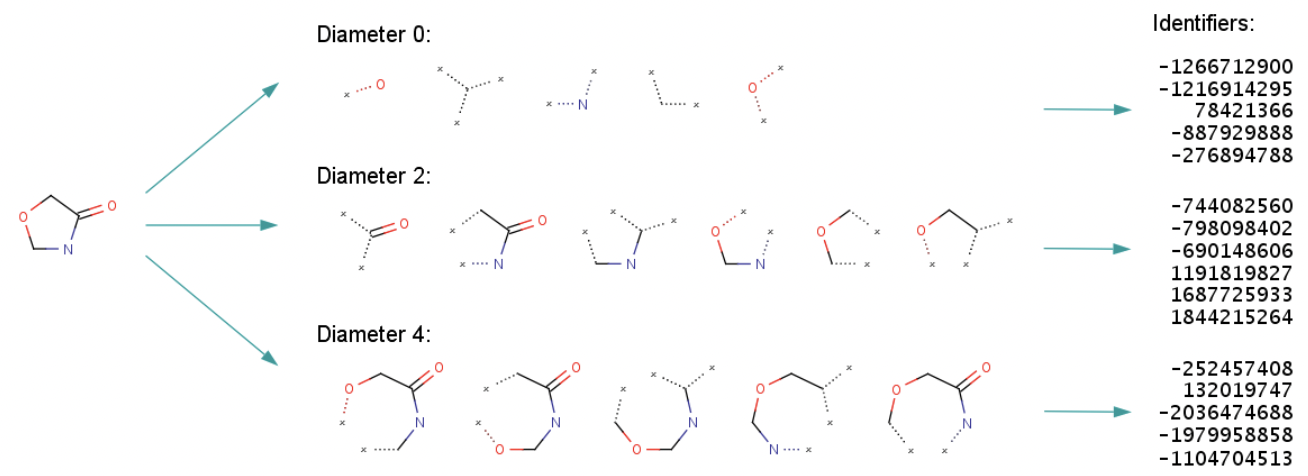

Les sous-graphes sont ensuite transformés en un vecteur binaire : 


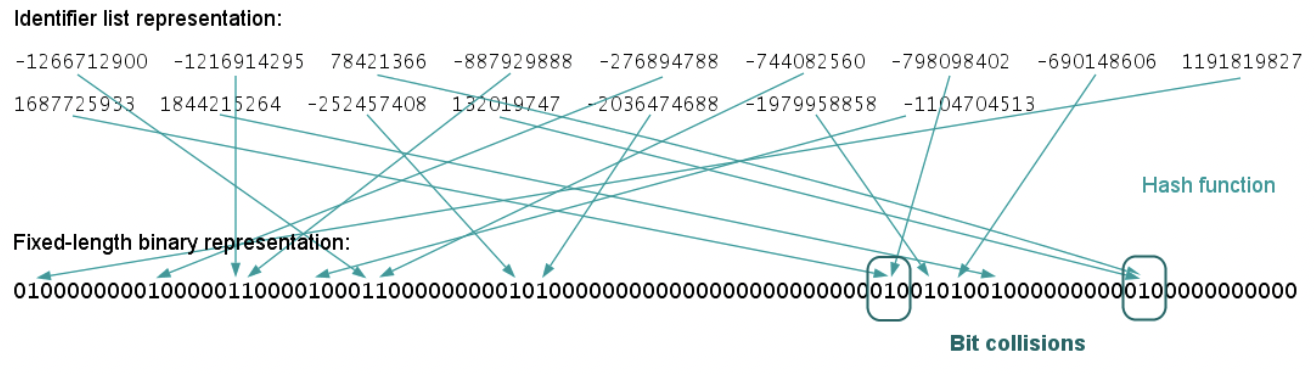

Ce processus est similaire à celui utilisé dans un algorithme de **NLP**.  
Pour générer les **ECFP**, nous utilisons la **librairie RDKit**, qui fait référence dans ce domaine.

Ce notebook utilise en partie nos fonctions présentes dans notre librairie **drug_smile**, bien qu'un certain nombre d'étapes soit simplifié. Entre autres, ce projet a été conçu pour utiliser les **buckets GCP** afin de sauvegarder les données et les modèles. Dans cet exemple, nous travaillerons uniquement en **local** et de manière simplifiée.

Les étapes principales incluent :
1. **Prétraitement des données**
2. **Entraînement d’un modèle**
3. **Prédiction des résultats**

N'oubliez pas Installez la librairie et ses dépendances avec :
```bash
pip install .
```
Les librairies dont vous aurez absolument besoin pour ce notebook sont :
- rdkit==2024.3.5
- duckdb==1.0.0

## 0. Variables d'environnement

Assurez-vous d'avoir copié-collé le .env.sample afin d'avoir un .env tel que :

NB_SAMPLE='10k'

NAME_PROTEIN='BRD4'

NAME_VECT_MODEL='Logistic Regression'

CHUNK_SIZE = 2000

Les autres variables d'environnement ne sont pas importantes pour ce notebook.

In [12]:
from dotenv import load_dotenv
import os

# Recharger explicitement le fichier .env
load_dotenv(override=True)

# Vérifier si les modifications sont prises en compte
name_protein = os.getenv("NAME_PROTEIN") # 10k
nb_sample = os.getenv("NB_SAMPLE") # BDR4
name_vect_model = os.getenv("NAME_VECT_MODEL") # Logistic Regression
chunk_size = os.getenv("CHUNK_SIZE") # 2000
print(nb_sample)  # Affiche la valeur actuelle de NB_SAMPLE
print(name_protein)
print(name_vect_model)
print(chunk_size)

10k
BRD4
Logistic Regression
2000


Si jamais vous n'arrivez toujours pas à mettre à jour les varaibles d'environnement, quitter le notebook et rouvrez-le.

## 1. Pré-traitement des données

Toutes les données sont disponibles dans le projet Kaggle : [https://www.kaggle.com/competitions/leash-BELKA/data](https://www.kaggle.com/competitions/leash-BELKA/data).

Dans cet exemple, nous allons nous concentrer uniquement sur la protéine **BRD4** pour **10k molécules**. Un exemple d'échantillon **équilibré** (50-50)est disponible dans le dossier **raw_data**.

In [13]:
import pandas as pd

name_file = f"df_{name_protein}_{nb_sample}.parquet"

# Définit explicitement le répertoire racine du projet
parent_dir = os.getcwd()
raw_data = os.path.join(parent_dir, f'raw_data/{name_file}')
pd.read_parquet(raw_data)

,id,buildingblock1_smiles,buildingblock2_smiles,buildingblock3_smiles,molecule_smiles,protein_name,binds
0,193037064,O=C(Nc1ccc(C(=O)O)cc1OC(F)(F)F)OCC1c2ccccc2-c2...,COC(=O)c1nc(Cl)c(Cl)nc1N,Cl.Cn1cc(N)ccc1=O,COC(=O)c1nc(Cl)c(Cl)nc1Nc1nc(Nc2ccc(=O)n(C)c2)...,BRD4,0
1,260777526,O=C(O)C[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc21)c1c...,Cc1ccc(O)c(CN)n1.Cl.Cl,Cl.Cl.NCc1ncccc1F,Cc1ccc(O)c(CNc2nc(NCc3ncccc3F)nc(N[C@H](CC(=O)...,BRD4,0
2,240339957,O=C(O)CNC(=O)OCC1c2ccccc2-c2ccccc21,Cl.NCc1cocn1,CS(=O)(=O)c1ccc(N)cc1F,CS(=O)(=O)c1ccc(Nc2nc(NCC(=O)N[Dy])nc(NCc3cocn...,BRD4,0
3,252336978,O=C(O)C[C@@H](Cc1cccc(F)c1)NC(=O)OCC1c2ccccc2-...,Cl.NCc1nnc(-c2ccncc2)[nH]1,NCC1CCCCC(F)(F)C1,O=C(C[C@@H](Cc1cccc(F)c1)Nc1nc(NCc2nnc(-c3ccnc...,BRD4,0
4,70594803,N#Cc1cccc(C[C@H](CC(=O)O)NC(=O)OCC2c3ccccc3-c3...,Nc1cc(F)c(F)cc1Br,N#Cc1ccsc1N,N#Cc1cccc(C[C@H](CC(=O)N[Dy])Nc2nc(Nc3cc(F)c(F...,BRD4,0
...,...,...,...,...,...,...,...
9995,16872960,CC(C)(C)OCC(NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)O,Cl.Cn1cc(N)ccc1=O,Cc1cnc(F)c(CN)c1,Cc1cnc(F)c(CNc2nc(Nc3ccc(=O)n(C)c3)nc(NC(COC(C...,BRD4,1
9996,19318473,CC(OC(C)(C)C)C(NC(=O)OCC1c2ccccc2-c2ccccc21)C(...,NCc1c[nH]c2ccccc12,Cc1ccsc1CN,Cc1ccsc1CNc1nc(NCc2c[nH]c3ccccc23)nc(NC(C(=O)N...,BRD4,1
9997,74468415,O=C(NC(Cc1ccccc1)C(=O)O)OCC1c2ccccc2-c2ccccc21,Cc1cc(O)cc(C)c1N,NCc1cnns1,Cc1cc(O)cc(C)c1Nc1nc(NCc2cnns2)nc(NC(Cc2ccccc2...,BRD4,1
9998,19372731,CC(OC(C)(C)C)C(NC(=O)OCC1c2ccccc2-c2ccccc21)C(...,Nc1cc(Cl)c(O)c(Cl)c1,Cn1cc(N)cn1,CC(OC(C)(C)C)C(Nc1nc(Nc2cc(Cl)c(O)c(Cl)c2)nc(N...,BRD4,1


In [14]:
from drug_smile._01_preprocessing.vect_preproc import vect_check_and_process_file

# Utilisation d'une fonction qui récupère les données et réalise le pré-processing (encodage en ECFP)
df_encoded = vect_check_and_process_file()
df_encoded

Le fichier df_vect_preproc_BRD4_10k.pkl n'existe pas dans le bucket. Sauvegarde en cours...
---------------- Data downloaded on local file ----------------
Nombre de duplicat : 0
Nombre total de NaN dans le DataFrame : 0
------------------- START smile transformation into molecule -------------------
Processing chunk 1
------------------- START molecule transformation into ECFP for chunk 1 -------------------


[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerator
[12:46:00] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 1 -------------------
Processing chunk 2
------------------- START molecule transformation into ECFP for chunk 2 -------------------


[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerator
[12:46:03] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 2 -------------------
Processing chunk 3
------------------- START molecule transformation into ECFP for chunk 3 -------------------


...

[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerator
[12:46:08] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 4 -------------------
Processing chunk 5
------------------- START molecule transformation into ECFP for chunk 5 -------------------


[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerator
[12:46:10] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 5 -------------------
------------------- FINISHED processing all chunks -------------------
Le fichier df_vect_preproc_BRD4_10k.pkl a été sauvegardé localement.
Le fichier df_vect_preproc_BRD4_10k.pkl n'a pas pu être sauvegardé dans le bucket GCP.


,id,molecule_smiles,protein_name,binds,molecule,ecfp
0,193037064,COC(=O)c1nc(Cl)c(Cl)nc1Nc1nc(Nc2ccc(=O)n(C)c2)...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x33188bca0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,260777526,Cc1ccc(O)c(CNc2nc(NCc3ncccc3F)nc(N[C@H](CC(=O)...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x33188bd80>,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ..."
2,240339957,CS(=O)(=O)c1ccc(Nc2nc(NCC(=O)N[Dy])nc(NCc3cocn...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x33188bed0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
3,252336978,O=C(C[C@@H](Cc1cccc(F)c1)Nc1nc(NCc2nnc(-c3ccnc...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x33188be60>,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,70594803,N#Cc1cccc(C[C@H](CC(=O)N[Dy])Nc2nc(Nc3cc(F)c(F...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x33188bd10>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
...,...,...,...,...,...,...
9995,16872960,Cc1cnc(F)c(CNc2nc(Nc3ccc(=O)n(C)c3)nc(NC(COC(C...,BRD4,1,<rdkit.Chem.rdchem.Mol object at 0x3430b7f40>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9996,19318473,Cc1ccsc1CNc1nc(NCc2c[nH]c3ccccc23)nc(NC(C(=O)N...,BRD4,1,<rdkit.Chem.rdchem.Mol object at 0x3430b8040>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
9997,74468415,Cc1cc(O)cc(C)c1Nc1nc(NCc2cnns2)nc(NC(Cc2ccccc2...,BRD4,1,<rdkit.Chem.rdchem.Mol object at 0x3430b80b0>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9998,19372731,CC(OC(C)(C)C)C(Nc1nc(Nc2cc(Cl)c(O)c(Cl)c2)nc(N...,BRD4,1,<rdkit.Chem.rdchem.Mol object at 0x3430b8120>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Voici un **DataFrame** indiquant si chaque couple **molécule-protéine** est lié ou non.

Pour rappel, dans notre exemple, seule la protéine **BRD4** est étudiée.

Les molécules sont fournies au format **SMILES** (colonne *molecule_smiles*), puis transformées en objets **RDKit** (colonne *molecule*), et enfin en format **ECFP**. C'est sur ce format **ECFP** que nous allons entraîner notre modèle.

## 2. Entraînement d’un modèle

Une fois que nos **10k données** représentant les couples **molécule-protéine** sont prétraitées, nous pouvons **entraîner** et évaluer un modèle.  
Nous nous concentrerons uniquement sur une **Logistic Regression** dans cet exemple. Le nom du modèle a été **défini** comme variable d'environnement dans le fichier **.env**.

In [15]:
print(name_vect_model)

Logistic Regression


La métrique utilisée ici est celle recommandée dans le challenge Kaggle, à savoir l'**average precision score** (**AP score**), comme explicité ici :  
[https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.average_precision_score.html](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.average_precision_score.html).

L'**AP score** mesure la qualité du modèle en prenant en compte :  
- La **precision** (proportion de prédictions correctes parmi les positifs prédits).  
- Le **recall** (proportion de positifs détectés parmi les vrais positifs).

L'**AP score** résume une courbe **precision-recall** comme la moyenne pondérée des **precisions** obtenues à chaque seuil de **recall**, avec une pondération égale à l'augmentation du **recall** par rapport au seuil précédent.


In [16]:
from drug_smile._02_model_train.vect_train import vect_split_data, vect_train_and_evaluate

# Division des données
X_train, X_val, y_train, y_val = vect_split_data(df_encoded)

# Entraînement et évaluation
model, name_model = vect_train_and_evaluate(name_vect_model, X_train, X_val, y_train, y_val)


------------------------------------------------------------
Logistic Regression avec C=10, max_iter=1000, solver='lbfgs':
  - Average Precision: 0.9622

Modèle enregistré à : /Users/lucassedran/code/Lucas-Sedran/drug_smile/models/model_vect_Logistic_Regression_BRD4_10k.pkl

Le modèle n'a pas été enregistré dans le bucket de GCP
Le modèle n'a pas pu être mis à jour dans le bucket GCP
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1537
           1       0.90      0.90      0.90      1463

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000

------------------------------------------------------------


## 2bis. Pré-traitement & Entraînement d’un modèle
Sinon nous pouvons aussi réaliser le **pré-traitement**, **l'entrainement** et **l'évaluation** du modèle en une **seule commande** :

In [17]:
from drug_smile._02_model_train.registry import main_vecteurs

main_vecteurs(name_protein, nb_sample)

----- get_vecteurs_model BRD4 10k : START -----
Le fichier df_vect_preproc_BRD4_10k.pkl n'existe pas dans le bucket. Sauvegarde en cours...
---------------- Data downloaded on local file ----------------
Nombre de duplicat : 0
Nombre total de NaN dans le DataFrame : 0
------------------- START smile transformation into molecule -------------------
Processing chunk 1
------------------- START molecule transformation into ECFP for chunk 1 -------------------


[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerator
[12:46:17] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 1 -------------------
Processing chunk 2
------------------- START molecule transformation into ECFP for chunk 2 -------------------


[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerator
[12:46:20] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 2 -------------------
Processing chunk 3
------------------- START molecule transformation into ECFP for chunk 3 -------------------


...

------------------- STOP molecule transformation into ECFP for chunk 3 -------------------
Processing chunk 4
------------------- START molecule transformation into ECFP for chunk 4 -------------------


[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerator
[12:46:25] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 4 -------------------
Processing chunk 5
------------------- START molecule transformation into ECFP for chunk 5 -------------------


[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerator
[12:46:28] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 5 -------------------
------------------- FINISHED processing all chunks -------------------
Le fichier df_vect_preproc_BRD4_10k.pkl a été sauvegardé localement.
Le fichier df_vect_preproc_BRD4_10k.pkl n'a pas pu être sauvegardé dans le bucket GCP.

------------------------------------------------------------
Logistic Regression avec C=10, max_iter=1000, solver='lbfgs':
  - Average Precision: 0.9622

Modèle enregistré à : /Users/lucassedran/code/Lucas-Sedran/drug_smile/models/model_vect_Logistic_Regression_BRD4_10k.pkl

Le modèle n'a pas été enregistré dans le bucket de GCP
Le modèle n'a pas pu être mis à jour dans le bucket GCP
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1537
           1       0.90      0.90      0.90      1463

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.9

# 3. Prédiction des résultats

Pour la partie prédiction, nous ne pouvons pas utiliser directement nos pipelines déjà codés, car ils utilisent par défaut des modèles entraînés sur toutes les données (1 million de molécules) pour chacune des 3 protéines (soit 3 millions de couples molécule-protéine).

Restons dans notre exemple avec notre **Régression Logistique** entraînée sur **10k données**, uniquement pour la protéine **BRD4**. Prenons à présent une nouvelle base de données de **5k couples molécule-protéine** (toujours pour la protéine **BRD4**) afin de prédire leur liaison :

In [18]:
parent_dir = os.getcwd()
file_path = os.path.join(parent_dir, f'raw_data/df_BRD4_5k.parquet')
df_new = pd.read_parquet(file_path)
df_new

,id,buildingblock1_smiles,buildingblock2_smiles,buildingblock3_smiles,molecule_smiles,protein_name,binds
0,130312113,O=C(N[C@H]1CCC[C@@H]1C(=O)O)OCC1c2ccccc2-c2ccc...,Cl.NCc1nnc(-c2ccncc2)[nH]1,CS(=O)CCCCN,CS(=O)CCCCNc1nc(NCc2nnc(-c3ccncc3)[nH]2)nc(N[C...,BRD4,0
1,134988402,O=C(Nc1c(Br)cc(F)cc1C(=O)O)OCC1c2ccccc2-c2ccccc21,Nc1cccc2c(=O)[nH][nH]c(=O)c12,CCC1=NN(Cc2ccccc2C)C(=O)C1CCN,CCC1=NN(Cc2ccccc2C)C(=O)C1CCNc1nc(Nc2c(Br)cc(F...,BRD4,0
2,222819051,O=C(Nc1nc(-c2ccc(C(=O)O)cc2)cs1)OCC1c2ccccc2-c...,Cl.NCC1CC2CC1C1CC21,Cn1cc(CN)cn1,Cn1cc(CNc2nc(NCC3CC4CC3C3CC43)nc(Nc3nc(-c4ccc(...,BRD4,0
3,28349427,COc1c(F)ccc(C(=O)O)c1NC(=O)OCC1c2ccccc2-c2ccccc21,CC(=O)c1cccc(N)c1,Cl.Cl.NCc1nc2c(F)c(F)ccc2[nH]1,COc1c(F)ccc(C(=O)N[Dy])c1Nc1nc(NCc2nc3c(F)c(F)...,BRD4,0
4,138695544,O=C(Nc1c(C(=O)O)ccc2ccccc12)OCC1c2ccccc2-c2ccc...,Cc1c(N)cccc1F,Nc1ccc(Cl)nc1Cl,Cc1c(F)cccc1Nc1nc(Nc2ccc(Cl)nc2Cl)nc(Nc2c(C(=O...,BRD4,0
...,...,...,...,...,...,...,...
4995,97877922,O=C(N[C@@H](Cc1ccc(F)c(F)c1)C(=O)O)OCC1c2ccccc...,Nc1ccc(N2CCC(N3CCOCC3)CC2)cc1,CCOC(=O)c1ncccc1N,CCOC(=O)c1ncccc1Nc1nc(Nc2ccc(N3CCC(N4CCOCC4)CC...,BRD4,0
4996,74348001,O=C(NC(Cc1ccccc1)C(=O)O)OCC1c2ccccc2-c2ccccc21,COc1ccc(Cl)c(N)c1.Cl,Cl.NCC12CC3CC(CC(C3)C1)C2,COc1ccc(Cl)c(Nc2nc(NCC34CC5CC(CC(C5)C3)C4)nc(N...,BRD4,0
4997,125219115,O=C(N[C@H](Cc1ccc(I)cc1)C(=O)O)OCC1c2ccccc2-c2...,Nc1cncc(F)c1,Nc1nc(Cl)c(C=O)c(Cl)n1,O=Cc1c(Cl)nc(Nc2nc(Nc3cncc(F)c3)nc(N[C@H](Cc3c...,BRD4,0
4998,71899128,O=C(CC[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)...,Nc1ncncc1Br,Cc1ccc([N+](=O)[O-])c(N)n1,Cc1ccc([N+](=O)[O-])c(Nc2nc(Nc3ncncc3Br)nc(N[C...,BRD4,0


In [19]:
print(f"Nombre de target = 0 : {(df_new['binds'] == 0).sum()}/{(df_new['binds']).count()} ({(df_new['binds'] == 0).sum()/(df_new['binds']).count()}%)")
print(f"Nombre de target = 1 : {(df_new['binds'] == 1).sum()}/{(df_new['binds']).count()} ({(df_new['binds'] == 1).sum()/(df_new['binds']).count()}%)")

Nombre de target = 0 : 4980/5000 (0.996%)
Nombre de target = 1 : 20/5000 (0.004%)


**Note :** Comme vous pouvez le voir, les données à prédire sont largement **déséquilibrées** ! La classe 1 ne représente que 0.004% des données.

Nous pouvons à présent réalisé le **pré-traitement** des nouvelles données :

In [20]:
from drug_smile._01_preprocessing.vect_preproc import vect_preprocess_data

preproc_df_new = vect_preprocess_data(df_new)
preproc_df_new

------------------- START smile transformation into molecule -------------------
Processing chunk 1
------------------- START molecule transformation into ECFP for chunk 1 -------------------


[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerator
[12:46:34] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 1 -------------------
Processing chunk 2
------------------- START molecule transformation into ECFP for chunk 2 -------------------


[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerator
[12:46:37] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 2 -------------------
Processing chunk 3
------------------- START molecule transformation into ECFP for chunk 3 -------------------


[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerator
[12:46:40] DEPRECATION WARNING: please use MorganGenerat

------------------- STOP molecule transformation into ECFP for chunk 3 -------------------
------------------- FINISHED processing all chunks -------------------


[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerator
[12:46:41] DEPRECATION WARNING: please use MorganGenerat

,id,buildingblock1_smiles,buildingblock2_smiles,buildingblock3_smiles,molecule_smiles,protein_name,binds,molecule,ecfp
0,130312113,O=C(N[C@H]1CCC[C@@H]1C(=O)O)OCC1c2ccccc2-c2ccc...,Cl.NCc1nnc(-c2ccncc2)[nH]1,CS(=O)CCCCN,CS(=O)CCCCNc1nc(NCc2nnc(-c3ccncc3)[nH]2)nc(N[C...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x36768fa00>,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,134988402,O=C(Nc1c(Br)cc(F)cc1C(=O)O)OCC1c2ccccc2-c2ccccc21,Nc1cccc2c(=O)[nH][nH]c(=O)c12,CCC1=NN(Cc2ccccc2C)C(=O)C1CCN,CCC1=NN(Cc2ccccc2C)C(=O)C1CCNc1nc(Nc2c(Br)cc(F...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x36768f530>,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,222819051,O=C(Nc1nc(-c2ccc(C(=O)O)cc2)cs1)OCC1c2ccccc2-c...,Cl.NCC1CC2CC1C1CC21,Cn1cc(CN)cn1,Cn1cc(CNc2nc(NCC3CC4CC3C3CC43)nc(Nc3nc(-c4ccc(...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x36768f990>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,28349427,COc1c(F)ccc(C(=O)O)c1NC(=O)OCC1c2ccccc2-c2ccccc21,CC(=O)c1cccc(N)c1,Cl.Cl.NCc1nc2c(F)c(F)ccc2[nH]1,COc1c(F)ccc(C(=O)N[Dy])c1Nc1nc(NCc2nc3c(F)c(F)...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x36768f7d0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,138695544,O=C(Nc1c(C(=O)O)ccc2ccccc12)OCC1c2ccccc2-c2ccc...,Cc1c(N)cccc1F,Nc1ccc(Cl)nc1Cl,Cc1c(F)cccc1Nc1nc(Nc2ccc(Cl)nc2Cl)nc(Nc2c(C(=O...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x36768fbc0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...
4995,97877922,O=C(N[C@@H](Cc1ccc(F)c(F)c1)C(=O)O)OCC1c2ccccc...,Nc1ccc(N2CCC(N3CCOCC3)CC2)cc1,CCOC(=O)c1ncccc1N,CCOC(=O)c1ncccc1Nc1nc(Nc2ccc(N3CCC(N4CCOCC4)CC...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x372fa6340>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4996,74348001,O=C(NC(Cc1ccccc1)C(=O)O)OCC1c2ccccc2-c2ccccc21,COc1ccc(Cl)c(N)c1.Cl,Cl.NCC12CC3CC(CC(C3)C1)C2,COc1ccc(Cl)c(Nc2nc(NCC34CC5CC(CC(C5)C3)C4)nc(N...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x372fa63b0>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4997,125219115,O=C(N[C@H](Cc1ccc(I)cc1)C(=O)O)OCC1c2ccccc2-c2...,Nc1cncc(F)c1,Nc1nc(Cl)c(C=O)c(Cl)n1,O=Cc1c(Cl)nc(Nc2nc(Nc3cncc(F)c3)nc(N[C@H](Cc3c...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x372fa6420>,"[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4998,71899128,O=C(CC[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)...,Nc1ncncc1Br,Cc1ccc([N+](=O)[O-])c(N)n1,Cc1ccc([N+](=O)[O-])c(Nc2nc(Nc3ncncc3Br)nc(N[C...,BRD4,0,<rdkit.Chem.rdchem.Mol object at 0x372fa6490>,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Nous pouvons maintenant calculer les **prédictions de probabilités** et les **prédictions de classe**.  

**À noter :**
- Les prédictions de classe se font par défaut avec un seuil de **0.5**, mais ce seuil peut être modifié manuellement.
- Le modèle a été sauvegardé dans la variable **`model`**, que nous pouvons réutiliser. Il a également été enregistré localement dans le dossier **models**. Nous pourrions alors le télécharger depuis ce dossier en utilisant le code commenté ci-dessous.

In [21]:
# import joblib

# # Charger le modèle
# model_name = f"model_vect_{name_model.replace(' ','_')}_{name_protein}_{nb_sample}.pkl"

# parent_dir = os.getcwd()
# chemin_fichier = os.path.join(parent_dir, f'models/{model_name}')
# model = joblib.load(chemin_fichier)

# print(f"----- {model_name} model loaded -----")

In [22]:
from sklearn.metrics import average_precision_score, classification_report

# Convertir la colonne 'ecfp' en liste de listes
X = preproc_df_new['ecfp'].tolist()
# Notre target
y_true = df_new['binds']

# Prédictions de probabilités
y_proba = model.predict_proba(X)[:, 1]

# Calcul de l'AP score
ap_score = average_precision_score(y_true, y_proba)

# Affichage des résultats
print('\n------------------------------------------------------------')

print(f"  - Average Precision: {ap_score:.4f}")

# Prédictions
#threshold = 0.7
#y_pred = (y_proba >= threshold).astype(int)
y_pred = model.predict(X)

# Affichage du rapport de classification
print(classification_report(y_true, y_pred))
print('------------------------------------------------------------')

y_pred = pd.DataFrame(y_pred, columns=['pred'])
df_concatenated_temps = pd.concat([df_new, y_pred], axis=1)
df_concatenated_temps = df_concatenated_temps.drop(columns=['buildingblock1_smiles','buildingblock2_smiles','buildingblock3_smiles'])
#df_concatenated_temps.columns = ['id', 'molecule_smiles', 'protein_name', 'target','pred']
df_concatenated_temps


------------------------------------------------------------
  - Average Precision: 0.3144
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      4980
           1       0.03      0.85      0.06        20

    accuracy                           0.89      5000
   macro avg       0.51      0.87      0.50      5000
weighted avg       1.00      0.89      0.94      5000

------------------------------------------------------------


,id,molecule_smiles,protein_name,binds,pred
0,130312113,CS(=O)CCCCNc1nc(NCc2nnc(-c3ccncc3)[nH]2)nc(N[C...,BRD4,0,0
1,134988402,CCC1=NN(Cc2ccccc2C)C(=O)C1CCNc1nc(Nc2c(Br)cc(F...,BRD4,0,0
2,222819051,Cn1cc(CNc2nc(NCC3CC4CC3C3CC43)nc(Nc3nc(-c4ccc(...,BRD4,0,0
3,28349427,COc1c(F)ccc(C(=O)N[Dy])c1Nc1nc(NCc2nc3c(F)c(F)...,BRD4,0,0
4,138695544,Cc1c(F)cccc1Nc1nc(Nc2ccc(Cl)nc2Cl)nc(Nc2c(C(=O...,BRD4,0,0
...,...,...,...,...,...
4995,97877922,CCOC(=O)c1ncccc1Nc1nc(Nc2ccc(N3CCC(N4CCOCC4)CC...,BRD4,0,0
4996,74348001,COc1ccc(Cl)c(Nc2nc(NCC34CC5CC(CC(C5)C3)C4)nc(N...,BRD4,0,1
4997,125219115,O=Cc1c(Cl)nc(Nc2nc(Nc3cncc(F)c3)nc(N[C@H](Cc3c...,BRD4,0,0
4998,71899128,Cc1ccc([N+](=O)[O-])c(Nc2nc(Nc3ncncc3Br)nc(N[C...,BRD4,0,0


# 4. Discussion

**Comme nous pouvons le voir, l'AP score est bien plus mauvais ici (0.31) que durant l'évaluation du modèle (0.96) !!!**

Puisque nous passons d'une base **équilibrée** à une base **extrêmement déséquilibrée** :
- La classe majoritaire (**0**) domine totalement les prédictions.
- Les prédictions positives (**1**) deviennent rares, donc le modèle tend à prédire systématiquement **0**.
- Cela entraîne une faible précision pour la classe **1** (précision de **0.03**). La précision chute car, sur les rares prédictions positives faites, la majorité sont incorrectes. 

Toutefois, le **recall** pour la classe minoritaire **1** est bon (**0.85**), ce qui indique que le modèle détecte bien les vrais positifs, mais les prédictions positives restent très imprécises. Dans le cadre d'un projet en santé, il est souvent plus important d'avoir un **recall élevé**, c'est-à-dire de détecter un maximum de vrais positifs, quitte à avoir des faux positifs. Dans notre cas, on préférera détecter toutes les molécules qui pourraient se lier à la protéine **BRD4**, quitte à en supprimer dans les tests suivants, plutôt que de passer à côté de molécules qui auraient pu se lier.

Ainsi, l'AP score baisse car il sanctionne fortement :
- Les prédictions incorrectes positives (faible précision).
- Le manque de capacité à équilibrer précision et rappel pour la classe minoritaire.

Sur une base aussi déséquilibrée, un bon **recall** ne suffit pas si la **précision** est proche de 0.

**Solutions pour améliorer les performances sur des données déséquilibrées :**

**1. Rééquilibrage :**
- Au lieu d'équilibrer en **50-50**, nous pourrions équilibrer en **70-30** afin que le modèle soit mieux adapté à la réalité des données et devienne plus robuste aux distributions naturelles des classes.
- Utiliser des techniques plus robustes : **sur-échantillonnage des `1`** (*SMOTE, ADASYN*, etc.) ou **sous-échantillonnage des `0`**.

**2. Ajustement des seuils de décision :**
- Le modèle prédit des probabilités, mais utilise un seuil par défaut de **0.5** pour prédire les classes.
- Sur des données déséquilibrées, il peut être utile d'ajuster ce seuil pour augmenter la **précision pour la classe `1`**.

**3. Entraîner un modèle adapté aux données déséquilibrées :**
- Utiliser des modèles comme **XGBoost** ou **LightGBM** avec l'argument **`scale_pos_weight`** pour équilibrer l'impact des classes.


**Bonus :**

Vous pouvez essayer de modifier la variable d'environnement **`NAME_VECT_MODEL`** comme suit :  

```python
NAME_VECT_MODEL = 'Random Forest'
```
Relancez le code en vous assurant que la mise à jour des variables d'environnement a bien été effectuée. Vous devriez obtenir des **AP scores** similaires :
- 0.9574 pour les données d'entraînement.
- 0.2911 pour les données de test.